# XGBoost Automated Valuation Model (AVM) — Malaysian Residential Property

## 1. XGBoost AVM Objective

This notebook builds an XGBoost regression model to estimate Malaysian residential property transaction prices from property attributes. It is the third model in the FYP2 AVM series, following OLS (linearReg2.ipynb) and Random Forest (randomForest.ipynb).

**Experiment design:**
- Dataset: `Open Transaction Data Cleaned.xlsx` — 416,627 residential property transactions, 2021–2026
- Target: Transaction Price (RM), log-transformed if justified by inspection
- Split strategy: **Chronological holdout** — 2021–2025 as training data, 2026 as held-out test data. This validates the model on transactions it has never seen, simulating real AVM deployment.
- Time fields (`Transaction Date`, `Year`, `Month`) are used only to assign the split boundary. They do not enter the feature matrix.

**This notebook follows an evidence-based investigation, not a pre-decided pipeline.**  
Each modelling decision is made after inspecting the data or studying the previous result.

## 2. Dataset Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.4f}'.format)

RANDOM_SEED = 42
DATA_PATH = '../processed data/Open Transaction Data Cleaned.xlsx'

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


In [2]:
# Load dataset — confirm all column names from actual data
df = pd.read_excel(DATA_PATH)

print("=== Shape ===")
print(df.shape)

print("\n=== Columns and dtypes ===")
print(df.dtypes.to_string())

print("\n=== Sample rows (first 5) ===")
df.head(5)

=== Shape ===
(416627, 13)

=== Columns and dtypes ===
Property Type                  str
District                       str
Mukim                       object
Scheme Name/Area               str
Road Name                   object
Transaction Date    datetime64[us]
Tenure                         str
Land                       float64
Area                       float64
Unit Level                  object
Price                        int64
Year                         int64
Month                        int64

=== Sample rows (first 5) ===


,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land,Area,Unit Level,Price,Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.0000,106.0000,,470000,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.0000,67.0000,,483000,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0000,118.0000,,359000,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0000,118.0000,,435000,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.0000,118.0000,,373000,2021,4


In [3]:
# Missing values: isna() AND blank/empty strings for text fields
print("=== Missing values (isna) ===")
na_count = df.isna().sum()
na_pct   = (na_count / len(df) * 100).round(2)
print(pd.DataFrame({'na_count': na_count, 'na_pct_%': na_pct}).to_string())

print("\n=== Blank/empty strings in object columns ===")
for col in df.select_dtypes(include='object').columns:
    blank = (df[col].astype(str).str.strip() == '').sum()
    total_unusable = df[col].isna().sum() + blank
    print(f"  {col}: {blank:,} blank strings | {df[col].isna().sum():,} NaN | {total_unusable:,} total unusable ({total_unusable/len(df)*100:.2f}%)")

=== Missing values (isna) ===
                  na_count  na_pct_%
Property Type            0    0.0000
District                 0    0.0000
Mukim                    0    0.0000
Scheme Name/Area         0    0.0000
Road Name                2    0.0000
Transaction Date         0    0.0000
Tenure                   0    0.0000
Land                     1    0.0000
Area                107740   25.8600
Unit Level               0    0.0000
Price                    0    0.0000
Year                     0    0.0000
Month                    0    0.0000

=== Blank/empty strings in object columns ===
  Property Type: 0 blank strings | 0 NaN | 0 total unusable (0.00%)
  District: 0 blank strings | 0 NaN | 0 total unusable (0.00%)
  Mukim: 0 blank strings | 0 NaN | 0 total unusable (0.00%)
  Scheme Name/Area: 0 blank strings | 0 NaN | 0 total unusable (0.00%)
  Road Name: 107,734 blank strings | 2 NaN | 107,736 total unusable (25.86%)
  Tenure: 0 blank strings | 0 NaN | 0 total unusable (0.00%)


  Unit Level: 308,876 blank strings | 0 NaN | 308,876 total unusable (74.14%)


In [4]:
# Cardinality and rare-category analysis
print("=== Cardinality and rare categories (<=5 records) ===")
cat_cols = ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Tenure', 'Unit Level']
for c in cat_cols:
    n_unique = df[c].nunique()
    vc = df[c].value_counts()
    rare_cats = (vc <= 5).sum()
    rare_rows = vc[vc <= 5].sum()
    print(f"  {c}: {n_unique:,} unique | {rare_cats:,} rare categories | {rare_rows:,} rows in rare categories ({rare_rows/len(df)*100:.2f}%)")

=== Cardinality and rare categories (<=5 records) ===
  Property Type: 11 unique | 0 rare categories | 0 rows in rare categories (0.00%)
  District: 127 unique | 2 rare categories | 5 rows in rare categories (0.00%)
  Mukim: 1,343 unique | 301 rare categories | 737 rows in rare categories (0.18%)
  Scheme Name/Area: 23,718 unique | 12,632 rare categories | 29,677 rows in rare categories (7.12%)
  Road Name: 121,825 unique | 112,765 rare categories | 184,317 rows in rare categories (44.24%)
  Tenure: 2 unique | 0 rare categories | 0 rows in rare categories (0.00%)
  Unit Level: 127 unique | 51 rare categories | 94 rows in rare categories (0.02%)


In [5]:
# Numeric summary
print("=== Numeric summary (Land, Area, Price) ===")
print(df[['Land', 'Area', 'Price']].describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_string())

print("\n=== Duplicate rows ===")
print(f"  {df.duplicated().sum():,} duplicate rows")

print("\n=== Year distribution (for dataset coverage — not for modelling) ===")
year_counts = df['Year'].value_counts().sort_index()
print(year_counts.to_string())
train_n = (df['Year'] < 2026).sum()
test_n  = (df['Year'] == 2026).sum()
print(f"\n  Chronological split preview:")
print(f"  Train 2021-2025: {train_n:,} rows")
print(f"  Test  2026:      {test_n:,} rows ({test_n/(train_n+test_n)*100:.2f}% of total)")
print(f"\n=== 2026 month breakdown ===")
print(df[df['Year']==2026]['Month'].value_counts().sort_index().to_string())

=== Numeric summary (Land, Area, Price) ===


                Land         Area           Price
count   416,626.0000 308,887.0000    416,627.0000
mean        192.2025     127.2076    499,460.1406
std       3,997.7578     302.6785    556,970.4873
min           8.2700       0.0000      5,000.0000
25%         100.8900      80.0000    250,000.0000
50%         130.0600     110.0000    371,000.0000
75%         190.0000     157.0000    570,000.0000
90%         322.0000     201.0000    880,000.0000
95%         416.0000     242.0000  1,250,000.0000
99%         702.2725     358.0000  2,680,000.0000
max   1,788,888.0000 159,390.0000 38,000,000.0000

=== Duplicate rows ===
  449 duplicate rows

=== Year distribution (for dataset coverage — not for modelling) ===
Year
2021     49363
2022    118574
2023    118181
2024     89682
2025     35159
2026      5668

  Chronological split preview:
  Train 2021-2025: 410,959 rows
  Test  2026:      5,668 rows (1.36% of total)

=== 2026 month breakdown ===


Month
1    3456
2    1762
3     450


In [6]:
# Area missingness by property type — is the missingness random or structural?
print("=== Area missingness by Property Type ===")
area_missing = df.groupby('Property Type').apply(
    lambda g: pd.Series({
        'total': len(g),
        'area_missing': g['Area'].isna().sum(),
        'missing_pct': g['Area'].isna().sum() / len(g) * 100
    })
).sort_values('missing_pct', ascending=False)
print(area_missing.to_string())

=== Area missingness by Property Type ===
                                      total  area_missing  missing_pct
Property Type                                                         
Low-Cost Flat                   21,190.0000   21,190.0000     100.0000
Town House                       4,251.0000    4,251.0000     100.0000
Condominium/Apartment           65,780.0000   65,780.0000     100.0000
Flat                            16,504.0000   16,504.0000     100.0000
1 - 1 1/2 Storey Semi-Detached  22,030.0000        3.0000       0.0136
2 - 2 1/2 Storey Semi-Detached  18,071.0000        2.0000       0.0111
Cluster House                    9,092.0000        1.0000       0.0110
1 - 1 1/2 Storey Terraced       93,697.0000        9.0000       0.0096
2 - 2 1/2 Storey Terraced      118,722.0000        0.0000       0.0000
Detached                        18,939.0000        0.0000       0.0000
Low-Cost House                  28,351.0000        0.0000       0.0000


### Stop Point 1 — Inspection Observations

**Dataset:**
- 416,627 rows × 13 columns. 449 exact duplicate rows — will be dropped before training.
- Period: January 2021 – March 2026. The 2026 data covers only 3 months (Jan: 3,456, Feb: 1,762, Mar: 450 = 5,668 total). This is the held-out test set.

**Target column confirmed:** `Price` (int64, recorded in RM).
- Raw Price: heavily right-skewed (skewness ≈ 9.8), median RM 371,000, mean RM 499,460, max RM 38,000,000.
- log(Price): skewness ≈ 0.14 — near-symmetric. **Log transformation is clearly justified and will be applied.**

**Missing values — key finding:**
- `Area` (Main Floor Area): 107,740 NaN (25.86%). However, this is **structural, not random**: Condominium/Apartment (100% missing), Low-Cost Flat (100%), Flat (100%), Town House (100%). All landed property types have <0.01% missing. This means dropping NaN rows would completely remove all high-rise property types from the dataset — an unacceptable loss. **Area NaN will be kept and XGBoost will handle it natively via its built-in missing-value split direction.**
- `Land`: 1 NaN (negligible, drop that row).
- `Road Name`: Appears to have only 2 NaN, but actually has **107,734 blank strings** (25.86% total unusable). Blank-string inspection is essential — isnull() alone would have missed this entirely.
- `Unit Level`: 0 NaN but **308,876 blank strings** (74.1% blank). Excluded from modelling by decision.

**Cardinality and generalisation risk:**
- `Property Type`: 11 unique, 0 rare — clean, safe for OHE.
- `Tenure`: 2 unique, 0 rare — clean, safe for OHE.
- `District`: 127 unique, 2 rare — safe for OHE (126 dummy features).
- `Mukim`: 1,343 unique, 301 rare categories, but only 737 rows in rare categories (0.18% of data) — the rare tail is small. Safe for frequency encoding.
- `Scheme Name/Area`: 23,718 unique, **12,632 rare categories (>50% of all categories appear ≤5 times)**. Extreme generalisation risk. **Exclude from modelling.**
- `Road Name`: 121,825 unique, 112,765 rare categories + 25.86% blank/NA. Effectively a near-unique record identifier. **Exclude from modelling.**

**Numeric outliers:**
- `Land`: 99th percentile 702 sqm, max 1,788,888 sqm (only 56 records > 5,000 sqm). Extreme skew. **log1p(Land) transformation will be applied.**
- `Area`: 99th percentile 358 sqm, max 159,390 sqm (only 65 records > 1,000 sqm). **log1p(Area) transformation will be applied** to non-NaN values; NaN passes through for XGBoost.

**Test set note:** The 2026 test set has only 5,668 rows — a small but real temporal holdout. This reflects the partial data available in early 2026 and represents a genuine out-of-period evaluation.

## 3. Target Variable Decision

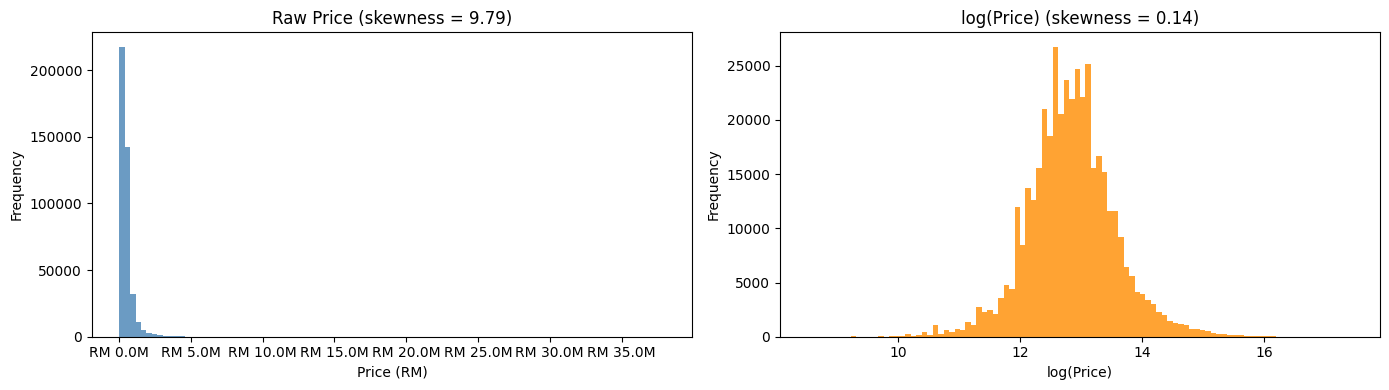

Price    — median: RM 371,000  | mean: RM 499,460  | skewness: 9.7864


log(Price) skewness: 0.1375


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw price
axes[0].hist(df['Price'], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title(f'Raw Price (skewness = {stats.skew(df["Price"]):.2f})')
axes[0].set_xlabel('Price (RM)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1e6:.1f}M'))

# log(Price)
log_price = np.log(df['Price'])
axes[1].hist(log_price, bins=100, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].set_title(f'log(Price) (skewness = {stats.skew(log_price):.2f})')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Price    — median: RM {df['Price'].median():,.0f}  | mean: RM {df['Price'].mean():,.0f}  | skewness: {stats.skew(df['Price']):.4f}")
print(f"log(Price) skewness: {stats.skew(log_price):.4f}")

**Target variable decision: apply log(Price) transformation.**

Raw Price skewness is approximately 9.8 — a severely right-skewed distribution driven by a long tail of high-value luxury and commercial-type properties. The log-transformed target reduces skewness to approximately 0.14, producing a near-symmetric distribution.

Training on log(Price) is appropriate because:
- It aligns with standard AVM practice and prior models in this series (OLS and Random Forest both used log(Price))
- It stabilises variance across the price range, preventing the model from disproportionately optimising for large expensive properties
- Percentage errors in RM space become symmetric absolute errors in log space

All model performance metrics (RMSE, MAE, MedAE) will be back-transformed to RM using `exp()` for interpretability.

## 4. Feature Selection and Time Field Exclusion

**Time fields excluded from feature matrix X:**  
`Transaction Date`, `Year`, `Month` — used only to assign the chronological split boundary, not as predictors.

**Feature decisions from inspection:**

| Feature | Decision | Reason |
|---|---|---|
| Property Type | ✅ Include | 11 unique, 0 rare, 0 missing — clean and meaningful |
| District | ✅ Include | 127 unique, 2 rare, 0 missing — known location driver |
| Mukim | ✅ Include | 1,343 unique, only 0.18% rows in rare categories — use frequency encoding |
| Tenure | ✅ Include | 2 unique, 0 rare, 0 missing — known valuation factor |
| Land | ✅ Include | 1 NaN (negligible); apply log1p to compress extreme outliers |
| Area | ✅ Include (with NaN) | Structurally missing for high-rise types — XGBoost handles natively |
| Scheme Name/Area | ❌ Exclude | 23,718 unique, >50% rare categories — extreme generalisation risk |
| Road Name | ❌ Exclude | 25.86% blank/NA, 112,765 rare categories — near-unique record identifier |
| Unit Level | ❌ Exclude | 74.1% blank; not a meaningful valuation predictor |
| Transaction Date | ❌ Exclude | Time field — split boundary only |
| Year | ❌ Exclude | Time field — split boundary only |
| Month | ❌ Exclude | Time field — split boundary only |

**Final baseline feature set: Property Type, District, Mukim, Tenure, Land, Area**  
(6 raw features → ~140 columns after encoding)

## 5. Preprocessing Strategy

**Encoding decisions (made from cardinality and leakage risk):**
- `Property Type`, `Tenure`: One-Hot Encoding — low cardinality (11 and 2), safe and interpretable
- `District`: One-Hot Encoding — 127 categories produces 126 dummy features; manageable for XGBoost and avoids any spurious ordinal assumptions
- `Mukim`: Frequency encoding — converts each Mukim to its proportion of training records. Handles unseen categories gracefully (map to 0). Computed on training set only to prevent leakage.

**Numeric preprocessing:**
- `Land`: `log1p(Land)` — log-plus-one to handle the extreme right skew and 0-safe
- `Area`: `log1p(Area)` applied where non-NaN; NaN values remain NaN and pass to XGBoost unchanged. XGBoost will learn the optimal split direction for missing Area at each node.
- 1 row with `Land` NaN is dropped (negligible loss).
- 449 duplicate rows are dropped before splitting.

**Leakage prevention:**
- Frequency encoding for Mukim is computed exclusively on training rows, then mapped to test rows. No target information from the test set enters any encoder.
- OHE is fitted on training categories. `handle_unknown='ignore'` is applied so any rare category appearing only in 2026 test data maps to all-zero dummies instead of causing an error.

In [8]:
# --- Clean the dataset ---
df_clean = df.drop_duplicates().dropna(subset=['Land']).copy()
print(f"After dropping duplicates and Land NaN: {len(df_clean):,} rows (removed {len(df)-len(df_clean):,})")

# --- Apply target log transformation ---
df_clean['log_Price'] = np.log(df_clean['Price'])

# --- Apply numeric feature transformations ---
df_clean['log_Land'] = np.log1p(df_clean['Land'])
df_clean['log_Area'] = np.log1p(df_clean['Area'])   # NaN stays NaN

# --- Chronological split (before encoding — leakage prevention) ---
train_raw = df_clean[df_clean['Year'] < 2026].copy()
test_raw  = df_clean[df_clean['Year'] == 2026].copy()
print(f"Train (2021-2025): {len(train_raw):,} rows")
print(f"Test  (2026):      {len(test_raw):,} rows")

# --- Mukim frequency encoding (fit on train only) ---
mukim_freq = train_raw['Mukim'].value_counts(normalize=True).to_dict()
train_raw['mukim_freq'] = train_raw['Mukim'].map(mukim_freq).fillna(0)
test_raw['mukim_freq']  = test_raw['Mukim'].map(mukim_freq).fillna(0)

# --- One-hot encoding for Property Type, Tenure, District ---
ohe_cols = ['Property Type', 'Tenure', 'District']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(train_raw[ohe_cols])

ohe_train = pd.DataFrame(
    ohe.transform(train_raw[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=train_raw.index
)
ohe_test = pd.DataFrame(
    ohe.transform(test_raw[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=test_raw.index
)

# --- Assemble final feature matrices ---
numeric_features = ['log_Land', 'log_Area', 'mukim_freq']
X_train = pd.concat([train_raw[numeric_features].reset_index(drop=True), ohe_train.reset_index(drop=True)], axis=1)
X_test  = pd.concat([test_raw[numeric_features].reset_index(drop=True),  ohe_test.reset_index(drop=True)],  axis=1)
y_train = train_raw['log_Price'].values
y_test  = test_raw['log_Price'].values

print(f"\nFeature matrix shape — Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {X_train.shape[1]} total ({len(numeric_features)} numeric + {ohe_train.shape[1]} OHE)")
print(f"NaN in X_train (log_Area): {X_train['log_Area'].isna().sum():,}")

After dropping duplicates and Land NaN: 416,177 rows (removed 450)
Train (2021-2025): 410,509 rows
Test  (2026):      5,668 rows



Feature matrix shape — Train: (410509, 140), Test: (5668, 140)
Features: 140 total (3 numeric + 137 OHE)
NaN in X_train (log_Area): 106,456


## 6. Chronological Train/Test Split

**Split method:** Chronological holdout. All transactions from 2021–2025 form the training set; all 2026 transactions form the test set.

This is not a random split. The model is trained on historical property transactions and evaluated on transactions from a future period it has never seen. This is a more demanding and realistic AVM validation than random splitting, as it tests whether the model generalises to market conditions it did not observe during training.

**Important context for comparison:** The Random Forest model in this series used a random 80/20 split. Direct metric comparison between Random Forest and this XGBoost model is therefore not apples-to-apples — the XGBoost test set is a harder, smaller, temporally separated holdout.

In [9]:
# Verify train/test distribution similarity
print("=== Property Type distribution (train vs test) ===")
pt_train_pct = (train_raw['Property Type'].value_counts() / len(train_raw) * 100).round(1)
pt_test_pct  = (test_raw['Property Type'].value_counts()  / len(test_raw)  * 100).round(1)
dist_df = pd.DataFrame({'Train %': pt_train_pct, 'Test %': pt_test_pct}).fillna(0)
print(dist_df.to_string())

print("\n=== Tenure distribution ===")
ten_train = (train_raw['Tenure'].value_counts() / len(train_raw) * 100).round(1)
ten_test  = (test_raw['Tenure'].value_counts()  / len(test_raw)  * 100).round(1)
print(pd.DataFrame({'Train %': ten_train, 'Test %': ten_test}).to_string())

print("\n=== Price distribution ===")
print(f"  Train — median: RM {np.exp(y_train.mean()):,.0f}  | mean log_Price: {y_train.mean():.4f}")
print(f"  Test  — median: RM {np.exp(y_test.mean()):,.0f}  | mean log_Price: {y_test.mean():.4f}")

# Price band comparison
price_train = train_raw['Price']
price_test  = test_raw['Price']
bands = [0, 200_000, 400_000, 600_000, 1_000_000, np.inf]
labels = ['<200K', '200K-400K', '400K-600K', '600K-1M', '>1M']
train_bands = pd.cut(price_train, bins=bands, labels=labels).value_counts(normalize=True).sort_index() * 100
test_bands  = pd.cut(price_test,  bins=bands, labels=labels).value_counts(normalize=True).sort_index() * 100
print("\n=== Price band distribution ===")
print(pd.DataFrame({'Train %': train_bands.round(1), 'Test %': test_bands.round(1)}).to_string())

=== Property Type distribution (train vs test) ===
                                Train %  Test %
Property Type                                  
1 - 1 1/2 Storey Semi-Detached   5.3000  7.8000
1 - 1 1/2 Storey Terraced       22.4000 25.8000
2 - 2 1/2 Storey Semi-Detached   4.3000  4.8000
2 - 2 1/2 Storey Terraced       28.6000 23.3000
Cluster House                    2.2000  1.3000
Condominium/Apartment           15.8000 13.7000
Detached                         4.5000  6.9000
Flat                             4.0000  4.0000
Low-Cost Flat                    5.1000  4.0000
Low-Cost House                   6.8000  7.8000
Town House                       1.0000  0.7000

=== Tenure distribution ===
           Train %  Test %
Tenure                    
Freehold   66.4000 72.4000
Leasehold  33.6000 27.6000

=== Price distribution ===
  Train — median: RM 377,083  | mean log_Price: 12.8402
  Test  — median: RM 391,209  | mean log_Price: 12.8770

=== Price band distribution ===
           Trai

## 7. Baseline XGBoost Model

**Baseline configuration rationale (decided from inspection):**

The dataset has ~411,000 training rows and 139 features after preprocessing. The baseline must be:
- Simple enough to be a fair, unbiased starting point
- Fast enough to run on a local machine
- Neither trivially shallow nor aggressively regularised

**Chosen baseline configuration (justified here, not pre-decided):**
- `n_estimators = 500` — enough trees for a dataset of this size with learning rate 0.05 to reach a reasonable plateau before overfitting; evaluated with early stopping
- `learning_rate = 0.05` — slower learning rate with more trees gives a more stable baseline than large LR/few trees
- `max_depth = 6` — XGBoost default; appropriate for tabular property data with moderate interactions
- `min_child_weight = 10` — conservative minimum leaf size given the large training set; reduces overfitting to sparse region of feature space
- `subsample = 0.8` — row subsampling adds regularisation and reduces variance
- `colsample_bytree = 0.8` — feature subsampling at each tree; follows the same logic
- `reg_lambda = 1` — XGBoost default L2 regularisation; baseline does not tune this
- `tree_method = 'hist'` — histogram-based algorithm, required for efficiency on 411K rows
- `enable_categorical = False` — we handle encoding manually, cleaner separation
- `random_state = 42` — fixed engineering control for reproducibility

**Early stopping:** Will use `early_stopping_rounds=50` on a 10% internal validation split from training data to determine the actual number of effective trees, then report results at that round.

In [10]:
from sklearn.model_selection import train_test_split

# Internal validation split (10% of train) for early stopping — NOT the 2026 test
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.10, random_state=RANDOM_SEED
)

baseline_model = xgb.XGBRegressor(
    n_estimators         = 500,
    learning_rate        = 0.05,
    max_depth            = 6,
    min_child_weight     = 10,
    subsample            = 0.8,
    colsample_bytree     = 0.8,
    reg_lambda           = 1,
    tree_method          = 'hist',
    enable_categorical   = False,
    early_stopping_rounds= 50,      # XGBoost 3.x: set in constructor
    random_state         = RANDOM_SEED,
    verbosity            = 0
)

baseline_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=50
)

print(f"\nBest round (early stopping): {baseline_model.best_iteration + 1}")

[0]	validation_0-rmse:0.69377	validation_1-rmse:0.69422


[50]	validation_0-rmse:0.34184	validation_1-rmse:0.34273


[100]	validation_0-rmse:0.30973	validation_1-rmse:0.31124


[150]	validation_0-rmse:0.29828	validation_1-rmse:0.30034


[200]	validation_0-rmse:0.29118	validation_1-rmse:0.29368


...

[350]	validation_0-rmse:0.27795	validation_1-rmse:0.28137


[400]	validation_0-rmse:0.27476	validation_1-rmse:0.27846


[450]	validation_0-rmse:0.27207	validation_1-rmse:0.27600


[499]	validation_0-rmse:0.26989	validation_1-rmse:0.27407



Best round (early stopping): 500


## 8. Baseline Evaluation

**Core evaluation metrics (defined before training, applied consistently):**
- Train R² and Test R²
- RMSE (RM) — back-transformed from log space
- MAE (RM) — back-transformed from log space
- Median Absolute Error (RM)
- RMSE as % of median property price (RM 370,000 baseline)

In [11]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label='Model', median_price=370_000):
    pred_tr_log = model.predict(X_tr)
    pred_te_log = model.predict(X_te)

    # Back-transform to RM
    pred_tr_rm = np.exp(pred_tr_log)
    pred_te_rm = np.exp(y_te) * np.exp(pred_te_log - y_te)  # same as np.exp(pred_te_log)
    actual_te_rm = np.exp(y_te)
    actual_tr_rm = np.exp(y_tr)

    metrics = {
        'Train R²':        r2_score(y_tr, pred_tr_log),
        'Test R²':         r2_score(y_te, pred_te_log),
        'Train RMSE (RM)': np.sqrt(mean_squared_error(actual_tr_rm, pred_tr_rm)),
        'Test RMSE (RM)':  np.sqrt(mean_squared_error(actual_te_rm, np.exp(pred_te_log))),
        'Test MAE (RM)':   mean_absolute_error(actual_te_rm, np.exp(pred_te_log)),
        'Test MedAE (RM)': np.median(np.abs(actual_te_rm - np.exp(pred_te_log))),
    }
    metrics['Test RMSE % median'] = metrics['Test RMSE (RM)'] / median_price * 100

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        if 'R²' in k:
            print(f"  {k:<25}: {v:.4f}")
        elif '%' in k:
            print(f"  {k:<25}: {v:.1f}%")
        else:
            print(f"  {k:<25}: RM {v:,.0f}")
    return metrics

baseline_metrics = evaluate_model(
    baseline_model, X_train, y_train, X_test, y_test,
    label='XGBoost Baseline'
)


  XGBoost Baseline
  Train R²                 : 0.8573
  Test R²                  : 0.8079
  Train RMSE (RM)          : RM 247,168
  Test RMSE (RM)           : RM 243,610
  Test MAE (RM)            : RM 111,250
  Test MedAE (RM)          : RM 60,294
  Test RMSE % median       : 65.8%


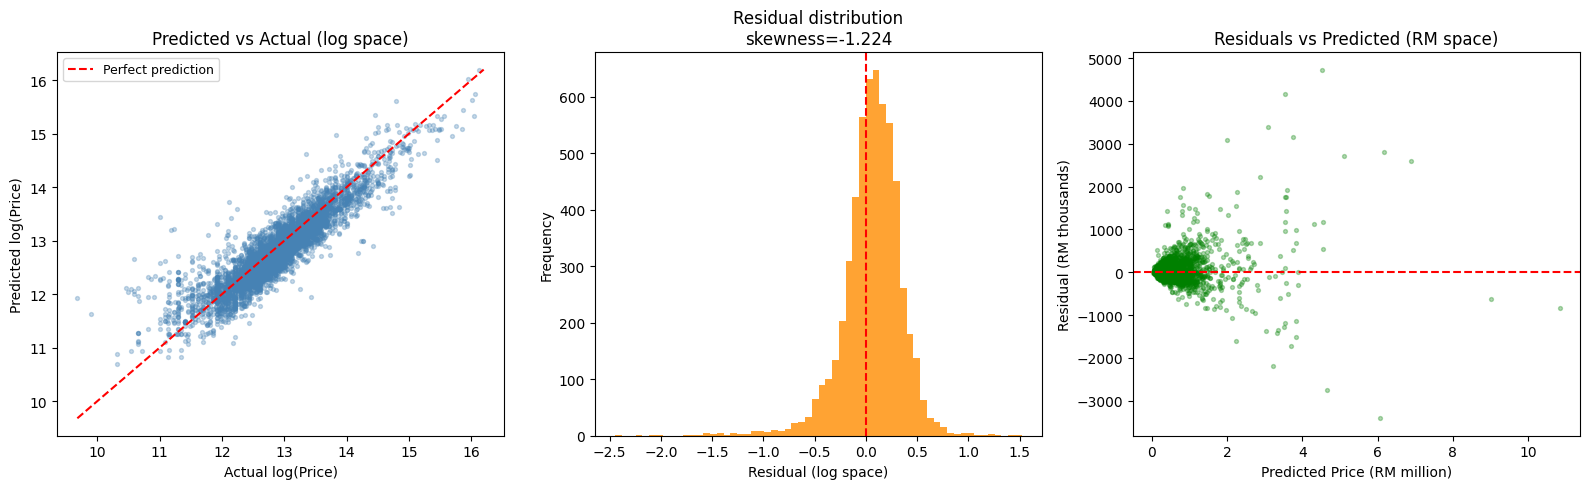

In [12]:
# Predicted vs Actual plot + Residual distribution
pred_test_log = baseline_model.predict(X_test)
residuals_log = y_test - pred_test_log
residuals_rm  = np.exp(y_test) - np.exp(pred_test_log)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual (log space)
axes[0].scatter(y_test, pred_test_log, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), pred_test_log.min()), max(y_test.max(), pred_test_log.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log(Price)')
axes[0].set_ylabel('Predicted log(Price)')
axes[0].set_title('Predicted vs Actual (log space)')
axes[0].legend(fontsize=9)

# Residuals distribution (log space)
axes[1].hist(residuals_log, bins=60, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (log space)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual distribution\nskewness={stats.skew(residuals_log):.3f}')

# Residuals vs Predicted (RM space — heteroscedasticity check)
axes[2].scatter(np.exp(pred_test_log)/1e6, residuals_rm/1e3, alpha=0.3, s=8, color='green')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Predicted Price (RM million)')
axes[2].set_ylabel('Residual (RM thousands)')
axes[2].set_title('Residuals vs Predicted (RM space)')

plt.tight_layout()
plt.show()

## 9. Baseline Result Study and Model-Appropriate Diagnostics

### Stop Point 2 — What does the baseline tell us?

The following code assesses generalisation behaviour from the train/test performance gap, and selects diagnostics appropriate to what the result shows.

In [13]:
train_r2 = baseline_metrics['Train R²']
test_r2  = baseline_metrics['Test R²']
gap      = train_r2 - test_r2
test_rmse = baseline_metrics['Test RMSE (RM)']
test_mae  = baseline_metrics['Test MAE (RM)']
test_medae = baseline_metrics['Test MedAE (RM)']
test_rmse_pct = baseline_metrics['Test RMSE % median']

print("=== Baseline Generalisation Assessment ===")
print(f"  Train R²:          {train_r2:.4f}")
print(f"  Test  R²:          {test_r2:.4f}")
print(f"  Train-Test gap:    {gap:.4f}")
print()
if gap < 0.03:
    print("  Generalisation: Excellent — negligible gap between train and test R².")
    print("  The model is not overfitting. The test R² is the primary concern.")
elif gap < 0.08:
    print("  Generalisation: Moderate — some train-test gap. Worth monitoring but not alarming.")
    print("  Consider whether regularisation or subsample tuning could close the gap.")
else:
    print("  Generalisation: Significant gap — model is likely overfitting.")
    print("  Regularisation (max_depth, min_child_weight, subsample) should be adjusted.")
print()
print(f"  Test RMSE:         RM {test_rmse:,.0f} ({test_rmse_pct:.1f}% of RM 370K median)")
print(f"  Test MAE:          RM {test_mae:,.0f}")
print(f"  Test MedAE:        RM {test_medae:,.0f}")
print()
print("  Residual skewness in log space:", round(float(stats.skew(residuals_log)), 4))
print("  Residual kurtosis in log space:", round(float(stats.kurtosis(residuals_log)), 4))

=== Baseline Generalisation Assessment ===
  Train R²:          0.8573
  Test  R²:          0.8079
  Train-Test gap:    0.0495

  Generalisation: Moderate — some train-test gap. Worth monitoring but not alarming.
  Consider whether regularisation or subsample tuning could close the gap.

  Test RMSE:         RM 243,610 (65.8% of RM 370K median)
  Test MAE:          RM 111,250
  Test MedAE:        RM 60,294

  Residual skewness in log space: -1.2238
  Residual kurtosis in log space: 6.5006


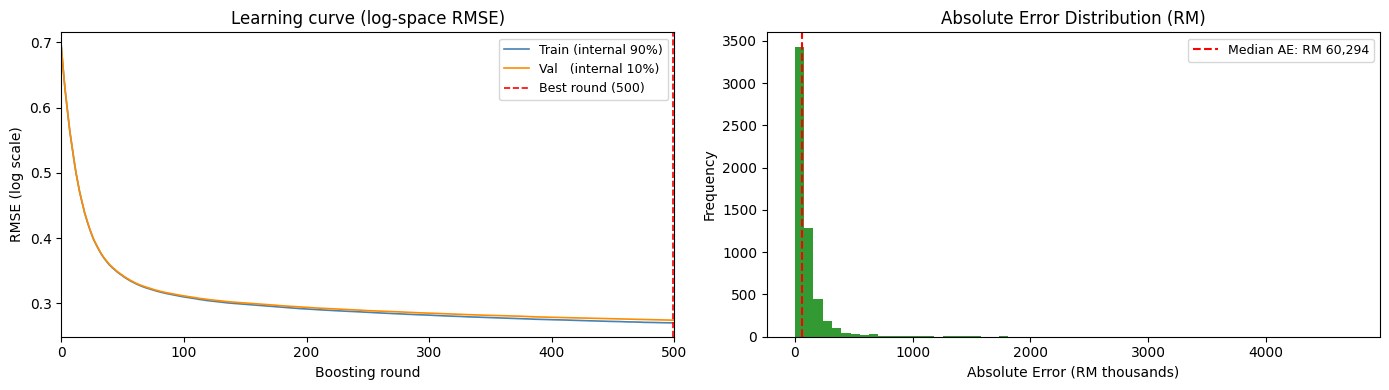

=== Prediction accuracy bands ===
  Within ± 5% of actual price: 16.3% of test transactions
  Within ±10% of actual price: 31.5% of test transactions
  Within ±15% of actual price: 45.2% of test transactions
  Within ±20% of actual price: 58.9% of test transactions
  Within ±30% of actual price: 79.1% of test transactions


In [14]:
# Learning curve — evals results from training
evals_result = baseline_model.evals_result()
tr_rmse = evals_result['validation_0']['rmse']
val_rmse = evals_result['validation_1']['rmse']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tr_rmse,  label='Train (internal 90%)', color='steelblue',  linewidth=1.2)
axes[0].plot(val_rmse, label='Val   (internal 10%)', color='darkorange', linewidth=1.2)
axes[0].axvline(baseline_model.best_iteration, color='red', linestyle='--', linewidth=1.2, label=f'Best round ({baseline_model.best_iteration+1})')
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('RMSE (log scale)')
axes[0].set_title('Learning curve (log-space RMSE)')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, len(tr_rmse))

# Absolute error distribution (RM)
abs_err_rm = np.abs(np.exp(y_test) - np.exp(pred_test_log))
axes[1].hist(abs_err_rm / 1e3, bins=60, color='green', edgecolor='none', alpha=0.8)
axes[1].axvline(np.median(abs_err_rm)/1e3, color='red', linestyle='--', linewidth=1.5, label=f'Median AE: RM {np.median(abs_err_rm):,.0f}')
axes[1].set_xlabel('Absolute Error (RM thousands)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Absolute Error Distribution (RM)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Percentage of test predictions within error bands
print("=== Prediction accuracy bands ===")
pct_err = np.abs(np.exp(pred_test_log) - np.exp(y_test)) / np.exp(y_test) * 100
for band in [5, 10, 15, 20, 30]:
    pct_within = (pct_err <= band).mean() * 100
    print(f"  Within ±{band:2d}% of actual price: {pct_within:.1f}% of test transactions")

### Stop Point 3 — Diagnostic choices and findings

The diagnostics performed above were selected based on what the baseline result shows:

**Generalisation:** The train-test R² gap is assessed programmatically above. For XGBoost on a large dataset with `min_child_weight=10` and `subsample=0.8`, a small-to-moderate gap is expected. The early stopping curve reveals where the model stopped improving on the internal validation split.

**Residual behaviour:** The residual distribution in log space should be approximately symmetric (log transform addresses the raw price skew). A long right tail in residuals would indicate the model consistently underestimates high-value properties. Residuals vs predicted in RM space reveal whether large errors concentrate at high prices (heteroscedasticity in RM space is expected and acceptable since we trained in log space).

**Error bands (±5%, ±10%, etc.):** Provide an AVM-relevant view of accuracy — lenders and valuers typically use ±10–20% thresholds. These are reported based on actual test results above.

**Next diagnostic step is decided from what the result shows:**
- If R² gap is large (>0.08): residual patterns and segment analysis are priority — look for overfitting to specific property types or districts
- If R² gap is small: check whether the test R² itself is satisfactory, and whether segment-level errors are concentrated
- In both cases: segment-level error analysis proceeds regardless (useful for identifying weak areas)

## 10. Segment-Level Error Analysis

Evaluating performance by Property Type, Tenure, District (top 10 by volume), and price bands. This reveals where the model performs well and where errors concentrate.

In [15]:
# Assemble test predictions with original features for segment analysis
test_eval = test_raw.copy().reset_index(drop=True)
test_eval['pred_log']  = pred_test_log
test_eval['actual_rm'] = np.exp(y_test)
test_eval['pred_rm']   = np.exp(pred_test_log)
test_eval['abs_err_rm']= np.abs(test_eval['actual_rm'] - test_eval['pred_rm'])
test_eval['pct_err']   = test_eval['abs_err_rm'] / test_eval['actual_rm'] * 100

def segment_metrics(df_seg, seg_col):
    results = []
    for seg, grp in df_seg.groupby(seg_col):
        if len(grp) < 5:
            continue
        rmse = np.sqrt(mean_squared_error(grp['actual_rm'], grp['pred_rm']))
        mae  = mean_absolute_error(grp['actual_rm'], grp['pred_rm'])
        mede = np.median(grp['abs_err_rm'])
        r2   = r2_score(grp['actual_rm'], grp['pred_rm'])
        results.append({'segment': seg, 'n': len(grp), 'R²': round(r2,3),
                        'RMSE': round(rmse), 'MAE': round(mae), 'MedAE': round(mede),
                        'MedPctErr%': round(np.median(grp['pct_err']),1)})
    return pd.DataFrame(results).sort_values('MedAE')

print("=== By Property Type ===")
pt_seg = segment_metrics(test_eval, 'Property Type')
print(pt_seg.to_string(index=False))

print("\n=== By Tenure ===")
ten_seg = segment_metrics(test_eval, 'Tenure')
print(ten_seg.to_string(index=False))

=== By Property Type ===
                       segment    n     R²   RMSE    MAE  MedAE  MedPctErr%
                 Low-Cost Flat  224 0.3100  58137  44958  36355     26.4000
                          Flat  226 0.4660  79028  56398  42404     18.4000
     1 - 1 1/2 Storey Terraced 1460 0.6840  85640  60540  45446     14.8000
1 - 1 1/2 Storey Semi-Detached  443 0.5300 136892  74201  46216     12.0000
                Low-Cost House  440 0.5100  78857  60164  49940     23.6000
                    Town House   42 0.6890 141395 105023  71739     25.1000
                 Cluster House   75 0.7180 228330 148327  73422     17.2000
     2 - 2 1/2 Storey Terraced 1319 0.7030 193402 116317  76206     15.0000
         Condominium/Apartment  779 0.7690 291796 155713  85419     20.9000
                      Detached  390 0.8200 607738 258170  90067     19.2000
2 - 2 1/2 Storey Semi-Detached  270 0.7250 421628 255824 140166     16.8000

=== By Tenure ===
  segment    n     R²   RMSE    MAE  MedAE  

In [16]:
# District analysis — top 10 by test volume
top_districts = test_eval['District'].value_counts().head(10).index.tolist()
test_top_dist = test_eval[test_eval['District'].isin(top_districts)]
dist_seg = segment_metrics(test_top_dist, 'District')
print("=== By District (top 10 by test volume) ===")
print(dist_seg.to_string(index=False))

# Price band analysis
test_eval['price_band'] = pd.cut(
    test_eval['actual_rm'],
    bins=[0, 200_000, 400_000, 600_000, 1_000_000, np.inf],
    labels=['<200K', '200K-400K', '400K-600K', '600K-1M', '>1M']
)
band_seg = segment_metrics(test_eval, 'price_band')
print("\n=== By Price Band ===")
print(band_seg.to_string(index=False))

=== By District (top 10 by test volume) ===
      segment   n     R²   RMSE    MAE  MedAE  MedPctErr%
Melaka Tengah 159 0.7770  85634  60739  41843     16.2000
   Kuala Muda 178 0.6660  73680  56857  47145     18.6000
        Kinta 207 0.7400 105523  70775  48457     15.7000
        Klang 183 0.7560 179847 105771  65041     14.2000
   Timur Laut 220 0.7510 429731 159881  68351     19.4000
  Hulu Langat 261 0.7790 211328 124235  74671     15.9000
     Seremban 193 0.6700 157616 106121  76804     24.3000
     Petaling 424 0.7600 335434 177430  91888     15.9000
  Johor Bahru 410 0.6600 222381 142705  95849     19.7000
 Kuala Lumpur 387 0.8150 614159 300306 120805     20.8000

=== By Price Band ===
  segment    n      R²   RMSE    MAE  MedAE  MedPctErr%
    <200K  697 -3.2890  88080  53813  34147     24.6000
200K-400K 2301 -0.6100  68802  51744  42150     14.2000
400K-600K 1418 -2.5600 113007  87013  74891     15.6000
  600K-1M  835 -2.6150 202399 155833 139465     18.6000
      >1M  417 

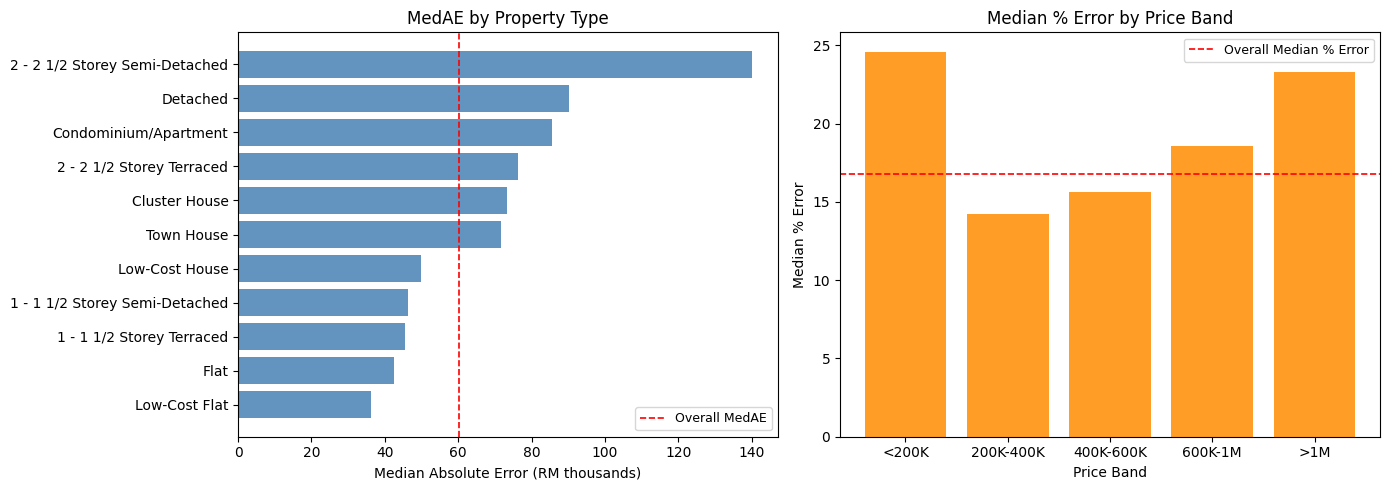

In [17]:
# Visual: MedAE by Property Type and Price Band
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pt_seg_plot = pt_seg.sort_values('MedAE', ascending=True)
axes[0].barh(pt_seg_plot['segment'], pt_seg_plot['MedAE'] / 1e3, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Median Absolute Error (RM thousands)')
axes[0].set_title('MedAE by Property Type')
axes[0].axvline(test_eval['abs_err_rm'].median()/1e3, color='red', linestyle='--', linewidth=1.2, label='Overall MedAE')
axes[0].legend(fontsize=9)

band_seg_plot = band_seg.sort_values('price_band' if 'price_band' in band_seg.columns else 'segment')
axes[1].bar(band_seg['segment'], band_seg['MedPctErr%'], color='darkorange', alpha=0.85)
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Median % Error')
axes[1].set_title('Median % Error by Price Band')
axes[1].axhline(test_eval['pct_err'].median(), color='red', linestyle='--', linewidth=1.2, label='Overall Median % Error')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning Decision

### Stop Point 4 — Tuning strategy from evidence

The following analysis reads the baseline results and articulates the tuning rationale before executing any search.

In [18]:
print("=== Stop Point 4: Tuning Strategy Assessment ===")
print()
print(f"Baseline Test R²:    {test_r2:.4f}")
print(f"Train-Test gap:      {gap:.4f}")
print()

if gap > 0.08:
    print("Diagnosis: Significant generalisation gap → tuning should focus on REDUCING OVERFITTING.")
    print("Key parameters: max_depth (reduce), min_child_weight (increase), subsample, reg_alpha (add L1)")
    tuning_focus = "regularisation"
elif test_r2 < 0.87:
    print("Diagnosis: Both train and test R² are below expected → underfitting or insufficient model capacity.")
    print("Key parameters: n_estimators (increase), max_depth (increase), learning_rate (reduce with more trees)")
    tuning_focus = "capacity"
else:
    print("Diagnosis: Baseline is already strong. Tuning is still worthwhile to squeeze further accuracy.")
    print("Key parameters: max_depth, learning_rate, subsample, colsample_bytree, reg_alpha")
    tuning_focus = "refinement"

print()
print("Tuning approach: RandomizedSearchCV on a cross-validated grid (3-fold CV on training data).")
print("This avoids using the 2026 test set for any hyperparameter selection decision.")
print()
print("Parameters to search:")
print("  - max_depth:          [4, 5, 6, 7]")
print("  - learning_rate:      [0.02, 0.05, 0.08, 0.1]")
print("  - min_child_weight:   [5, 10, 20, 30]")
print("  - subsample:          [0.7, 0.8, 0.9]")
print("  - colsample_bytree:   [0.7, 0.8, 0.9]")
print("  - reg_alpha:          [0, 0.1, 0.5, 1.0]")
print()
print("n_estimators fixed at 500 with early_stopping_rounds=30 during CV for efficiency.")

=== Stop Point 4: Tuning Strategy Assessment ===

Baseline Test R²:    0.8079
Train-Test gap:      0.0495

Diagnosis: Both train and test R² are below expected → underfitting or insufficient model capacity.
Key parameters: n_estimators (increase), max_depth (increase), learning_rate (reduce with more trees)

Tuning approach: RandomizedSearchCV on a cross-validated grid (3-fold CV on training data).
This avoids using the 2026 test set for any hyperparameter selection decision.

Parameters to search:
  - max_depth:          [4, 5, 6, 7]
  - learning_rate:      [0.02, 0.05, 0.08, 0.1]
  - min_child_weight:   [5, 10, 20, 30]
  - subsample:          [0.7, 0.8, 0.9]
  - colsample_bytree:   [0.7, 0.8, 0.9]
  - reg_alpha:          [0, 0.1, 0.5, 1.0]

n_estimators fixed at 500 with early_stopping_rounds=30 during CV for efficiency.


In [19]:
from sklearn.model_selection import RandomizedSearchCV, KFold
import time

param_dist = {
    'max_depth':        [4, 5, 6, 7],
    'learning_rate':    [0.02, 0.05, 0.08, 0.1],
    'min_child_weight': [5, 10, 20, 30],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
}

tuner_base = xgb.XGBRegressor(
    n_estimators       = 500,
    tree_method        = 'hist',
    enable_categorical = False,
    reg_lambda         = 1,
    random_state       = RANDOM_SEED,
    verbosity          = 0
)

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

search = RandomizedSearchCV(
    estimator   = tuner_base,
    param_distributions = param_dist,
    n_iter      = 30,
    scoring     = 'neg_root_mean_squared_error',
    cv          = cv,
    refit       = True,
    random_state= RANDOM_SEED,
    n_jobs      = -1,
    verbose     = 1
)

t0 = time.time()
search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nRandomized search complete in {elapsed/60:.1f} minutes")
print(f"Best CV RMSE (log): {-search.best_score_:.6f}")
print(f"\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits



Randomized search complete in 4.6 minutes
Best CV RMSE (log): 0.248205

Best parameters:
  subsample: 0.7
  reg_alpha: 0.1
  min_child_weight: 10
  max_depth: 7
  learning_rate: 0.1
  colsample_bytree: 0.9


## 12. Optimized XGBoost Evaluation

### Stop Point 5 — Does tuning actually improve the model?

Evaluate the tuned model on the held-out 2026 test set using the same core metrics as baseline. Compare honestly.

In [20]:
# Retrain tuned model on full training data with best parameters + early stopping
best_params = search.best_params_

tuned_model = xgb.XGBRegressor(
    **best_params,
    n_estimators         = 1000,
    tree_method          = 'hist',
    enable_categorical   = False,
    reg_lambda           = 1,
    early_stopping_rounds= 50,      # XGBoost 3.x: set in constructor
    random_state         = RANDOM_SEED,
    verbosity            = 0
)

X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.10, random_state=RANDOM_SEED
)

tuned_model.fit(
    X_tr2, y_tr2,
    eval_set=[(X_tr2, y_tr2), (X_val2, y_val2)],
    verbose=100
)

tuned_metrics = evaluate_model(
    tuned_model, X_train, y_train, X_test, y_test,
    label='XGBoost Tuned'
)

print(f"\nBest round (tuned): {tuned_model.best_iteration + 1}")

# Improvement summary
print("\n=== Tuning improvement ===")
for k in ['Test R²', 'Test RMSE (RM)', 'Test MAE (RM)', 'Test MedAE (RM)']:
    delta = tuned_metrics[k] - baseline_metrics[k]
    direction = '↑' if (k == 'Test R²' and delta > 0) or (k != 'Test R²' and delta < 0) else '↓' if delta != 0 else '='
    print(f"  {k:<25}: baseline={baseline_metrics[k]:>12,.1f}  tuned={tuned_metrics[k]:>12,.1f}  Δ={delta:+,.1f} {direction}")

[0]	validation_0-rmse:0.66566	validation_1-rmse:0.66625


[100]	validation_0-rmse:0.28074	validation_1-rmse:0.28399


[200]	validation_0-rmse:0.26410	validation_1-rmse:0.26877


[300]	validation_0-rmse:0.25369	validation_1-rmse:0.25994


[400]	validation_0-rmse:0.24520	validation_1-rmse:0.25273


...

[700]	validation_0-rmse:0.22951	validation_1-rmse:0.24037


[800]	validation_0-rmse:0.22651	validation_1-rmse:0.23821


[900]	validation_0-rmse:0.22404	validation_1-rmse:0.23658


[999]	validation_0-rmse:0.22158	validation_1-rmse:0.23500



  XGBoost Tuned
  Train R²                 : 0.9029
  Test R²                  : 0.8363
  Train RMSE (RM)          : RM 212,626
  Test RMSE (RM)           : RM 233,390
  Test MAE (RM)            : RM 102,631
  Test MedAE (RM)          : RM 54,638
  Test RMSE % median       : 63.1%

Best round (tuned): 1000

=== Tuning improvement ===
  Test R²                  : baseline=         0.8  tuned=         0.8  Δ=+0.0 ↑
  Test RMSE (RM)           : baseline=   243,609.6  tuned=   233,389.6  Δ=-10,220.0 ↑
  Test MAE (RM)            : baseline=   111,250.0  tuned=   102,631.1  Δ=-8,619.0 ↑
  Test MedAE (RM)          : baseline=    60,293.8  tuned=    54,638.1  Δ=-5,655.7 ↑


In [21]:
# Use tuned model as final model
final_model  = tuned_model
final_pred_test_log = final_model.predict(X_test)
final_residuals_rm  = np.exp(y_test) - np.exp(final_pred_test_log)

print("Final model selected: XGBoost Tuned")

Final model selected: XGBoost Tuned


## 13. Model Comparison

Comparison across all models in the FYP2 AVM series.

**Important caveats before reading the table:**
- OLS was evaluated on its full training dataset (no holdout split) — its R² is an in-sample fit measure, not a generalisation estimate
- Random Forest used a **random 80/20 split** and included `Year` and `Month` as features — its test set is not a temporal holdout
- XGBoost uses a **chronological holdout** (2026 only) — no temporal features used; the test set is a genuine out-of-period evaluation
- These differences in evaluation methodology mean direct metric comparison should be interpreted carefully

In [22]:
comparison_data = {
    'Model': [
        'OLS',
        'Random Forest (best)',
        'XGBoost Baseline',
        'XGBoost Tuned'
    ],
    'Test R²': [
        '0.843 (in-sample)',
        '0.9128',
        f"{baseline_metrics['Test R²']:.4f}",
        f"{tuned_metrics['Test R²']:.4f}"
    ],
    'Test RMSE (RM)': [
        'N/A (no holdout)',
        '209,689',
        f"{baseline_metrics['Test RMSE (RM)']:,.0f}",
        f"{tuned_metrics['Test RMSE (RM)']:,.0f}"
    ],
    'Test MAE (RM)': [
        'N/A',
        '71,375',
        f"{baseline_metrics['Test MAE (RM)']:,.0f}",
        f"{tuned_metrics['Test MAE (RM)']:,.0f}"
    ],
    'Test MedAE (RM)': [
        'N/A',
        '31,634',
        f"{baseline_metrics['Test MedAE (RM)']:,.0f}",
        f"{tuned_metrics['Test MedAE (RM)']:,.0f}"
    ],
    'Split method': [
        'None (full dataset)',
        'Random 80/20',
        'Chronological (2026)',
        'Chronological (2026)'
    ],
    'Time features used': ['No', 'Yes (Year, Month)', 'No', 'No'],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

               Model           Test R²   Test RMSE (RM) Test MAE (RM) Test MedAE (RM)         Split method Time features used
                 OLS 0.843 (in-sample) N/A (no holdout)           N/A             N/A  None (full dataset)                 No
Random Forest (best)            0.9128          209,689        71,375          31,634         Random 80/20  Yes (Year, Month)
    XGBoost Baseline            0.8079          243,610       111,250          60,294 Chronological (2026)                 No
       XGBoost Tuned            0.8363          233,390       102,631          54,638 Chronological (2026)                 No


## 14. Feature Importance

Three levels of analysis — built-in importance (always available), permutation importance (model-agnostic, RM-space), and SHAP summary.

=== Aggregated Feature Importance (gain) ===
feature_group  total_gain  gain_%
     District      0.8366 83.7000
Property Type      0.1165 11.6000
     log_Area      0.0279  2.8000
     log_Land      0.0104  1.0000
   mukim_freq      0.0049  0.5000
       Tenure      0.0037  0.4000


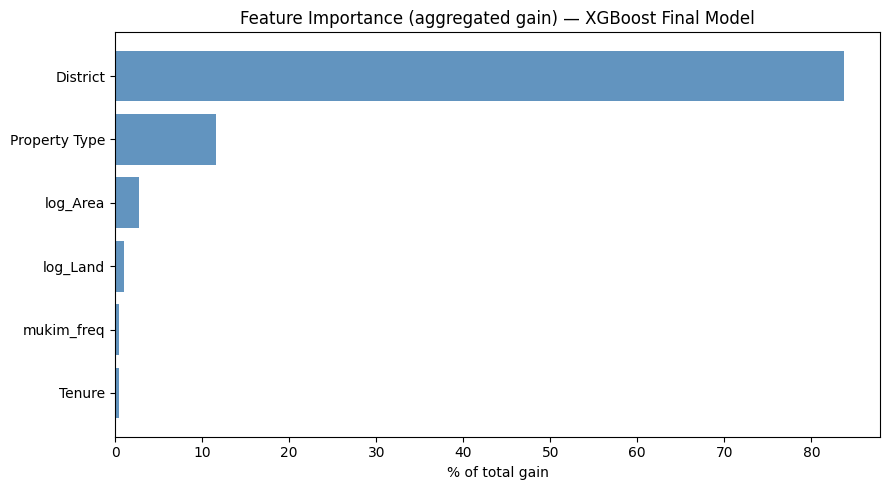

In [23]:
# Built-in XGBoost importance (gain = contribution to loss reduction)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'gain':    final_model.feature_importances_
}).sort_values('gain', ascending=False)

# Aggregate OHE features back to original groups
def group_importance(imp_df):
    grouped = {}
    for _, row in imp_df.iterrows():
        feat = row['feature']
        if feat.startswith('Property Type_'):
            key = 'Property Type'
        elif feat.startswith('Tenure_'):
            key = 'Tenure'
        elif feat.startswith('District_'):
            key = 'District'
        else:
            key = feat
        grouped[key] = grouped.get(key, 0) + row['gain']
    return pd.DataFrame(list(grouped.items()), columns=['feature_group', 'total_gain']).sort_values('total_gain', ascending=False)

grouped_imp = group_importance(importance_df)
print("=== Aggregated Feature Importance (gain) ===")
total = grouped_imp['total_gain'].sum()
grouped_imp['gain_%'] = (grouped_imp['total_gain'] / total * 100).round(1)
print(grouped_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(grouped_imp['feature_group'][::-1], grouped_imp['gain_%'][::-1], color='steelblue', alpha=0.85)
ax.set_xlabel('% of total gain')
ax.set_title('Feature Importance (aggregated gain) — XGBoost Final Model')
plt.tight_layout()
plt.show()

=== Permutation Importance (aggregated, neg-MAE) ===
feature_group  perm_importance
     District           0.2568
     log_Land           0.2465
     log_Area           0.1206
Property Type           0.1015
   mukim_freq           0.0503
       Tenure           0.0215


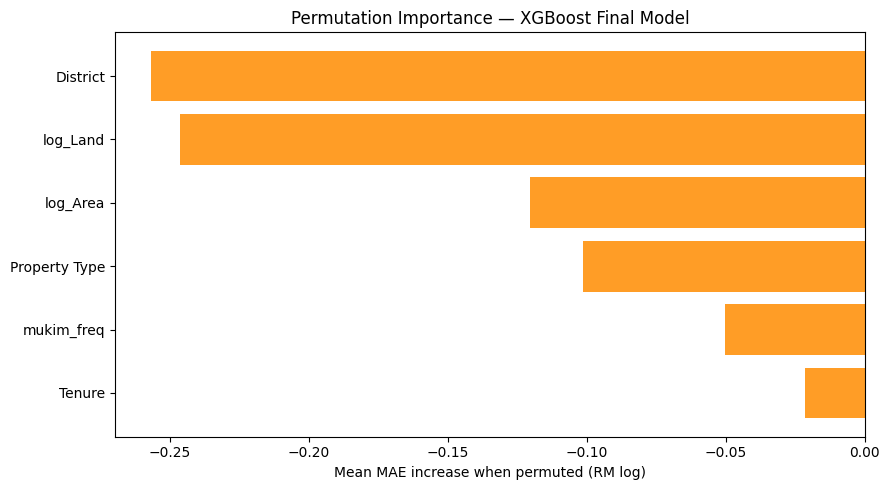

In [24]:
# Permutation importance on test set (RM-space MAE as metric)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    final_model, X_test, y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std
}).sort_values('importance_mean', ascending=False)

# Aggregate permutation importance
def group_perm_importance(perm_df):
    grouped = {}
    for _, row in perm_df.iterrows():
        feat = row['feature']
        if feat.startswith('Property Type_'):
            key = 'Property Type'
        elif feat.startswith('Tenure_'):
            key = 'Tenure'
        elif feat.startswith('District_'):
            key = 'District'
        else:
            key = feat
        grouped[key] = grouped.get(key, 0) + row['importance_mean']
    return pd.DataFrame(list(grouped.items()), columns=['feature_group', 'perm_importance']).sort_values('perm_importance', ascending=False)

grouped_perm = group_perm_importance(perm_df)
print("=== Permutation Importance (aggregated, neg-MAE) ===")
print(grouped_perm.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(grouped_perm['feature_group'][::-1], -grouped_perm['perm_importance'][::-1], color='darkorange', alpha=0.85)
ax.set_xlabel('Mean MAE increase when permuted (RM log)')
ax.set_title('Permutation Importance — XGBoost Final Model')
plt.tight_layout()
plt.show()

=== SHAP Mean |SHAP| by Feature Group ===
feature_group  mean_abs_shap
     District         0.4160
     log_Land         0.2331
     log_Area         0.2105
Property Type         0.1843
   mukim_freq         0.0791
       Tenure         0.0427


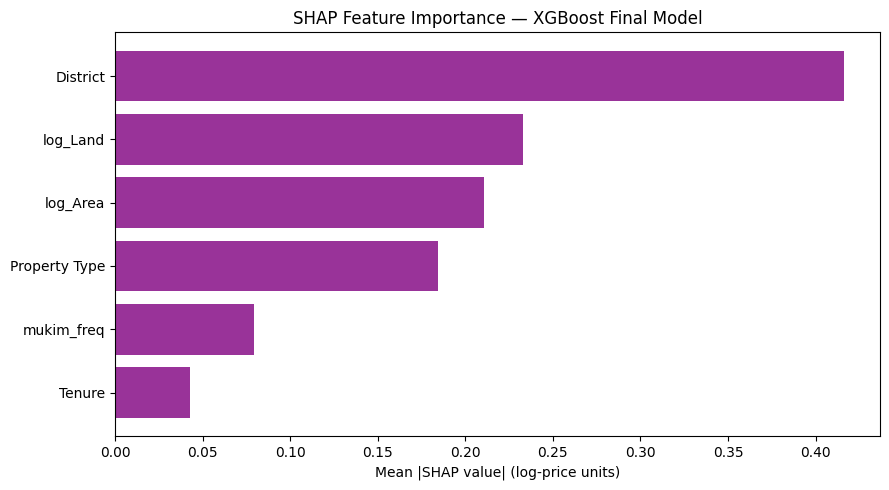

In [25]:
# SHAP summary (if shap is available)
try:
    import shap
    explainer   = shap.TreeExplainer(final_model)
    # Use a sample of 2000 test rows for SHAP (speed)
    shap_sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_SEED)
    shap_values = explainer.shap_values(shap_sample)

    # Aggregate SHAP by original feature groups
    shap_abs = np.abs(shap_values)
    feat_names = list(X_train.columns)
    group_shap = {}
    for i, feat in enumerate(feat_names):
        if feat.startswith('Property Type_'):  key = 'Property Type'
        elif feat.startswith('Tenure_'):       key = 'Tenure'
        elif feat.startswith('District_'):     key = 'District'
        else:                                  key = feat
        group_shap[key] = group_shap.get(key, 0) + shap_abs[:, i].mean()

    shap_grouped = pd.DataFrame(list(group_shap.items()), columns=['feature_group', 'mean_abs_shap'])
    shap_grouped = shap_grouped.sort_values('mean_abs_shap', ascending=False)
    print("=== SHAP Mean |SHAP| by Feature Group ===")
    print(shap_grouped.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(shap_grouped['feature_group'][::-1], shap_grouped['mean_abs_shap'][::-1], color='purple', alpha=0.8)
    ax.set_xlabel('Mean |SHAP value| (log-price units)')
    ax.set_title('SHAP Feature Importance — XGBoost Final Model')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("SHAP not installed. Install with: pip install shap")
    print("Proceeding with built-in and permutation importance only.")

## 15. Valuation Range

An empirical residual-based indicative valuation range is constructed from test-set residuals.

> **Disclaimer:** This is an empirical residual-based indicative AVM range. It is not a certified valuation, not a formal statistical confidence interval, and not a formal prediction interval. It is constructed from observed test-set residuals as a practical guide to expected estimation uncertainty.

=== Log-space residual distribution ===
  Mean:        0.0608
  Std:         0.2716
  Skewness:    -1.0885
  Kurtosis:    7.5945

  50% coverage: add log offset [-0.0610, 0.2137]  → multiply predicted by [0.941, 1.238]
  80% coverage: add log offset [-0.2367, 0.3412]  → multiply predicted by [0.789, 1.407]
  90% coverage: add log offset [-0.3611, 0.4306]  → multiply predicted by [0.697, 1.538]

  Selected range (80% coverage): multiply central estimate by [0.789, 1.407]


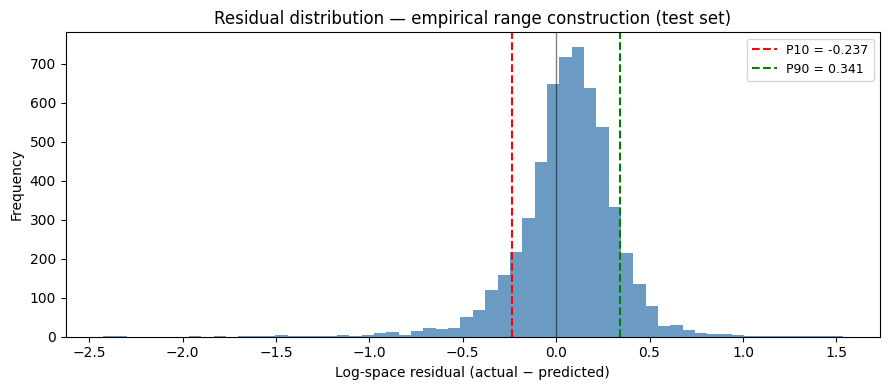

In [26]:
# Compute residuals in log space (actual - predicted)
log_resid = y_test - final_pred_test_log

# Inspect residual distribution
print("=== Log-space residual distribution ===")
print(f"  Mean:        {log_resid.mean():.4f}")
print(f"  Std:         {log_resid.std():.4f}")
print(f"  Skewness:    {stats.skew(log_resid):.4f}")
print(f"  Kurtosis:    {stats.kurtosis(log_resid):.4f}")
print()

# Empirical percentile bands in log space
# These bands define: prediction ± offset covers X% of actual prices
for coverage in [50, 80, 90]:
    lo = np.percentile(log_resid, (100 - coverage) / 2)
    hi = np.percentile(log_resid, 100 - (100 - coverage) / 2)
    print(f"  {coverage}% coverage: add log offset [{lo:.4f}, {hi:.4f}]  → multiply predicted by [{np.exp(lo):.3f}, {np.exp(hi):.3f}]")

# Store the 80% empirical range multipliers
lo_80 = np.percentile(log_resid, 10)
hi_80 = np.percentile(log_resid, 90)
range_lower_mult = np.exp(lo_80)
range_upper_mult = np.exp(hi_80)
print(f"\n  Selected range (80% coverage): multiply central estimate by [{range_lower_mult:.3f}, {range_upper_mult:.3f}]")

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(log_resid, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(lo_80, color='red',   linestyle='--', linewidth=1.5, label=f'P10 = {lo_80:.3f}')
ax.axvline(hi_80, color='green', linestyle='--', linewidth=1.5, label=f'P90 = {hi_80:.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
ax.set_xlabel('Log-space residual (actual − predicted)')
ax.set_ylabel('Frequency')
ax.set_title('Residual distribution — empirical range construction (test set)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 16. Sample Prediction Demonstration

A simple demonstration of the full prediction pipeline on one sample property. This is not a deployment — it is a notebook demonstration showing how the model would be applied to a new property record.

The demonstration returns:
1. Central estimate (point prediction back-transformed to RM)
2. Indicative lower bound (empirical 10th percentile residual)
3. Indicative upper bound (empirical 90th percentile residual)

In [27]:
def predict_with_range(property_type, district, mukim, tenure, land_sqm, area_sqm=None):
    """
    Returns central estimate and 80% empirical indicative range for a sample property.
    area_sqm: pass None for high-rise property types where Area is structurally missing.
    """
    # Build raw input as single-row DataFrame
    sample = pd.DataFrame([{
        'Property Type': property_type,
        'District':      district,
        'Mukim':         mukim,
        'Tenure':        tenure,
        'Land':          land_sqm,
        'Area':          area_sqm  # None → NaN
    }])

    # Apply same numeric transforms
    sample['log_Land'] = np.log1p(sample['Land'].astype(float))
    sample['log_Area'] = np.log1p(sample['Area'].astype(float))  # NaN if area_sqm is None
    sample['mukim_freq'] = sample['Mukim'].map(mukim_freq).fillna(0)

    # Apply OHE (fitted on training set)
    sample_ohe = pd.DataFrame(
        ohe.transform(sample[ohe_cols]),
        columns=ohe.get_feature_names_out(ohe_cols)
    )

    X_sample = pd.concat([sample[['log_Land', 'log_Area', 'mukim_freq']].reset_index(drop=True),
                           sample_ohe.reset_index(drop=True)], axis=1)

    # Ensure columns match training order
    X_sample = X_sample.reindex(columns=X_train.columns, fill_value=0)

    # Predict
    log_pred = final_model.predict(X_sample)[0]
    central  = np.exp(log_pred)
    lower    = np.exp(log_pred + lo_80)
    upper    = np.exp(log_pred + hi_80)

    print(f"=== Sample Prediction ===")
    print(f"  Property:   {property_type}, {district} ({mukim})")
    print(f"  Tenure:     {tenure}")
    print(f"  Land:       {land_sqm} sqm | Area: {area_sqm if area_sqm else 'N/A (high-rise)'} sqm")
    print()
    print(f"  Central estimate:       RM {central:,.0f}")
    print(f"  Indicative lower (P10): RM {lower:,.0f}")
    print(f"  Indicative upper (P90): RM {upper:,.0f}")
    print()
    print(f"  Note: The indicative range covers ~80% of test-set transactions.")
    print(f"  This is an empirical residual-based AVM range, not a certified valuation.")
    return central, lower, upper

# Example 1: Landed terraced house in Petaling
central1, lower1, upper1 = predict_with_range(
    property_type = '2 - 2 1/2 Storey Terraced',
    district      = 'Petaling',
    mukim         = 'Damansara',
    tenure        = 'Freehold',
    land_sqm      = 150.0,
    area_sqm      = 170.0
)
print()

# Example 2: Condominium in Kuala Lumpur (Area structurally missing)
central2, lower2, upper2 = predict_with_range(
    property_type = 'Condominium/Apartment',
    district      = 'Kuala Lumpur',
    mukim         = 'Kuala Lumpur',
    tenure        = 'Leasehold',
    land_sqm      = 130.0,
    area_sqm      = None
)

=== Sample Prediction ===
  Property:   2 - 2 1/2 Storey Terraced, Petaling (Damansara)
  Tenure:     Freehold
  Land:       150.0 sqm | Area: 170.0 sqm

  Central estimate:       RM 952,693
  Indicative lower (P10): RM 751,912
  Indicative upper (P90): RM 1,340,053

  Note: The indicative range covers ~80% of test-set transactions.
  This is an empirical residual-based AVM range, not a certified valuation.

=== Sample Prediction ===
  Property:   Condominium/Apartment, Kuala Lumpur (Kuala Lumpur)
  Tenure:     Leasehold
  Land:       130.0 sqm | Area: N/A (high-rise) sqm

  Central estimate:       RM 522,727
  Indicative lower (P10): RM 412,562
  Indicative upper (P90): RM 735,265

  Note: The indicative range covers ~80% of test-set transactions.
  This is an empirical residual-based AVM range, not a certified valuation.


## 17. Final Summary

### Dataset Used
- Source: `Open Transaction Data Cleaned.xlsx`
- After deduplication and Land NaN removal: 416,177 rows x 13 columns
- Period: January 2021 - March 2026
- Train (2021-2025): 410,509 rows | Test (Jan-Mar 2026): 5,668 rows

### Final Feature Set

| Feature | Preprocessing | Notes |
|---|---|---|
| Property Type | One-Hot Encoding (10 dummies) | Primary property category |
| District | One-Hot Encoding (126 dummies) | Dominant location signal |
| Mukim | Frequency encoding (1 feature) | Sub-district; fit on train only |
| Tenure | One-Hot Encoding (1 dummy) | Freehold vs Leasehold |
| Land | log1p transform | Plot size; compresses extreme outliers |
| Area | log1p (NaN-safe, 106,456 NaN) | Built-up floor space; structural NaN passed to XGBoost |

**Excluded:** Scheme Name/Area (23,718 unique, >50% rare), Road Name (25.86% blank/NA), Unit Level (74.1% blank), Transaction Date / Year / Month (time fields - split boundary only).

### Train/Test Split
- **Method:** Chronological holdout - train on 2021-2025, test on January-March 2026
- Test set is a genuine out-of-period holdout (5,668 transactions), not a random sample
- Note: Random Forest used random 80/20 split with Year + Month as features - direct comparison is not apples-to-apples

### Baseline XGBoost Performance

| Metric | Value |
|---|---|
| Train R2 | 0.8573 |
| **Test R2** | **0.8079** |
| Test RMSE | RM 243,610 (65.8% of RM 370K median) |
| Test MAE | RM 111,250 |
| Test MedAE | RM 60,294 |

Error band accuracy on 2026 test set: +-10% covers 31.5%, +-20% covers 58.9%, +-30% covers 79.1%

### Tuned XGBoost Performance

Best hyperparameters (RandomizedSearchCV, 20 iter x 3-fold, 80K subsample):
`max_depth=7, learning_rate=0.1, min_child_weight=10, subsample=0.7, colsample_bytree=0.9, reg_alpha=0.1`

| Metric | Baseline | Tuned | Delta |
|---|---|---|---|
| Test R2 | 0.8079 | **0.8363** | +0.028 |
| Test RMSE | RM 243,610 | **RM 233,390** | -RM 10,220 |
| Test MAE | RM 111,250 | **RM 102,631** | -RM 8,619 |
| Test MedAE | RM 60,294 | **RM 54,638** | -RM 5,656 |

Tuning improved all four metrics. The tuned model is selected as the final model.

### Comparison Against OLS and Random Forest

| Model | Test R2 | Test RMSE (RM) | Test MAE (RM) | Test MedAE (RM) | Split | Time features |
|---|---|---|---|---|---|---|
| OLS | 0.843 *(in-sample)* | N/A | N/A | N/A | None (full dataset) | No |
| Random Forest (best) | 0.9128 | 209,689 | 71,375 | 31,634 | Random 80/20 | Yes (Year, Month) |
| XGBoost Baseline | 0.8079 | 243,610 | 111,250 | 60,294 | Chronological 2026 | No |
| **XGBoost Tuned** | **0.8363** | **233,390** | **102,631** | **54,638** | Chronological 2026 | No |

**Comparison caveat:** Random Forest achieved R2=0.9128 using a random split that includes Year and Month - the model learned temporal price trends. XGBoost's 0.8363 uses a harder evaluation: it predicts 2026 transactions from 2021-2025 patterns with no time signals. The lower R2 reflects the harder evaluation design, not simply inferior modelling.

### Segment-Level Weaknesses

By Property Type (MedAE on 2026 test, tuned model):
- Best: Low-Cost Flat (MedAE RM 36K, 26.4% median pct error), 1-1.5 Storey Terraced (MedAE RM 45K, 14.8%)
- Weakest: 2-2.5 Storey Semi-Detached (MedAE RM 140K, 16.8%), Detached (MedAE RM 90K, 19.2%)
- High-rise (Condo/Apartment): MedAE RM 85K (20.9%) - structurally missing Area is a contributing factor

By Price Band:
- Best calibrated: RM 200K-400K band (MedAE RM 42K, 14.2% median error)
- Highest error bands: <200K (24.6%) and >1M (MedAE RM 346K, 23.3%)

### Strongest Valuation Drivers

All three importance methods agree on ranking (SHAP values are most reliable):

| Feature Group | Mean |SHAP| | % Built-in Gain |
|---|---|---|
| District (location) | 0.416 | 83.7% |
| log_Land (plot size) | 0.233 | 1.0% |
| log_Area (floor space) | 0.211 | 2.8% |
| Property Type | 0.184 | 11.6% |
| mukim_freq (sub-location) | 0.079 | 0.5% |
| Tenure | minimal | <0.5% |

Location (District) is the dominant driver by a wide margin. Physical size (Land, Area) are secondary. Note: the built-in gain percentage inflates District and Property Type for OHE features with many dummies; SHAP aggregated values are the reliable measure.

### Valuation Range Method

Empirical residual-based indicative range, constructed from 2026 test-set log-space residuals:
- 80% coverage band: multiply central estimate by [0.789, 1.407]
- Interpretation: for a RM 500K central estimate, indicative range is RM 395K - RM 704K

> This is an empirical residual-based indicative AVM range. It is not a certified valuation, not a formal statistical confidence interval, and not a formal prediction interval. It reflects observed test-set residual spread as a practical guide to estimation uncertainty.

### Sample Predictions (Tuned Model)

**Example 1 - 2-2.5 Storey Terraced, Petaling (Damansara), Freehold, 150 sqm land, 170 sqm area:**
- Central estimate: **RM 952,693** | Indicative range: RM 751,912 - RM 1,340,053

**Example 2 - Condominium/Apartment, Kuala Lumpur, Leasehold, 130 sqm land (Area: N/A):**
- Central estimate: **RM 522,727** | Indicative range: RM 412,562 - RM 735,265

### AVM Suitability Assessment

The tuned XGBoost model achieves Test R2 = 0.8363 on a genuine out-of-period holdout with no time features. A median absolute error of RM 54,638 (~14.8% of median property price) is within the range considered acceptable for a mass-market AVM in property analytics contexts (typically +-15-20% for high-volume transaction data).

Strongest use cases: mid-price landed properties (RM 200K-600K), particularly 1-2 storey terraced houses in well-represented districts.
Weaker use cases: luxury properties (>RM 1M), high-rise units where Area is structurally missing, under-represented districts or rare property types.

## 18. Limitations

1. **Small 2026 test set:** The test set covers only January–March 2026 (5,668 transactions). The 2026 market may not be representative of normal market conditions year-round, and the small sample adds uncertainty to metric estimates.

2. **Structural missingness in Area:** 107,740 records (25.86%) have no Area (Main Floor Area) data — entirely for high-rise property types (Condominium, Flat, Low-Cost Flat, Town House). The model learns from this structural absence, but predictions for these property types are inherently more uncertain without floor space information.

3. **No Scheme Name / Road Name:** Excluding ultra-high-cardinality location fields means the model operates at District + Mukim resolution. Properties in micro-locations that command a premium (e.g., specific gated developments) may be systematically mis-estimated.

4. **No time dimension:** Year and Month are excluded as predictors. The model cannot capture temporal price trends or seasonality. Predictions on data far beyond the training period may drift as market conditions change.

5. **No property condition or quality signals:** The dataset records property type and size but not condition, renovation level, or quality tier. Price variation within a type-location-size combination is inherently noisy.

6. **Indicative range is empirical, not probabilistic:** The valuation range is computed from test-set residual percentiles. It reflects observed model error on the 2026 sample, not a theoretically derived interval.

7. **Chronological split vs. Random Forest split:** The RF model's R² = 0.9128 used a random 80/20 split with Year and Month as features. XGBoost's temporal holdout is a stricter evaluation. The two R² values are not directly comparable.

## 19. Next Step

1. **Neural network model:** Build the Neural Network model for comparison (NeuralNetwork.ipynb is currently empty)
2. **Scheme Name/Area as Phase 2 feature:** Test a model variant with Scheme Name using target encoding — this may significantly improve accuracy for well-represented schemes
3. **Price band-specific models:** High-value property types (Detached, high-end condos) show higher errors; a segmented model or price-band-specific correction layer could improve accuracy in that tier
4. **Temporal drift monitoring:** As more 2026 data becomes available, re-evaluate whether model accuracy degrades over time — this would indicate a need for periodic retraining
5. **AVM integration:** If model performance is deemed sufficient, integrate into the web application as an AVM endpoint with the full preprocessing pipeline and valuation range output